# No-Show / Cancellation Prediction

**Goal:** for each booking, predict the probability that the customer won't show up.
Owners use this to flag risky bookings so they can confirm with the customer or
oversell the slot.

**The ML task:** *binary classification* — input = booking features, output = 0 (will show) or 1 (won't).

## 1. Load the data and check class balance

In classification, we always check **how rare each class is**. If only 8% of
bookings are no-shows, a dumb model that always predicts "will show" gets 92%
accuracy — and is useless. **Class imbalance changes how we measure success.**

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
df = pd.read_csv("../data/bookings_labeled.csv", parse_dates=["timestamp"])
print(f"Rows: {len(df):,}")
print(df["status"].value_counts(normalize=True).round(3))

# Treat both no_show and cancelled as "missed" (positive class)
df["is_missed"] = df["status"].isin(["no_show","cancelled"]).astype(int)
print(f"\nMissed rate: {df['is_missed'].mean():.1%}")
df.head()

Rows: 10,454
status
completed    0.743
no_show      0.209
cancelled    0.047
Name: proportion, dtype: float64

Missed rate: 25.7%


,timestamp,court_id,sport,district,day_of_week,hour,is_weekend,is_holiday,weather,price,n_courts,bookings,lead_time_days,is_repeat_customer,status,is_missed
0,2026-02-10 11:00:00,bbc-01,Badminton,Sukhumvit,1,11,False,False,rainy,450,4,1,2,True,no_show,1
1,2026-02-10 12:00:00,bbc-01,Badminton,Sukhumvit,1,12,False,False,rainy,450,4,1,6,True,completed,0
2,2026-02-10 13:00:00,bbc-01,Badminton,Sukhumvit,1,13,False,False,rainy,450,4,1,23,True,completed,0
3,2026-02-10 14:00:00,bbc-01,Badminton,Sukhumvit,1,14,False,False,rainy,450,4,1,29,False,cancelled,1
4,2026-02-10 15:00:00,bbc-01,Badminton,Sukhumvit,1,15,False,False,rainy,450,4,2,23,False,no_show,1


## 2. Visualize: who no-shows?

Looking at the miss rate broken down by each feature tells us which signals
the model will likely use.

/var/folders/rf/4sxqbs3d5tjg8t617zckblyx1rl7px/T/ipykernel_852/1210506651.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df["lead_time_days"], bins=[-1,3,7,14,30]))["is_missed"].mean().plot(


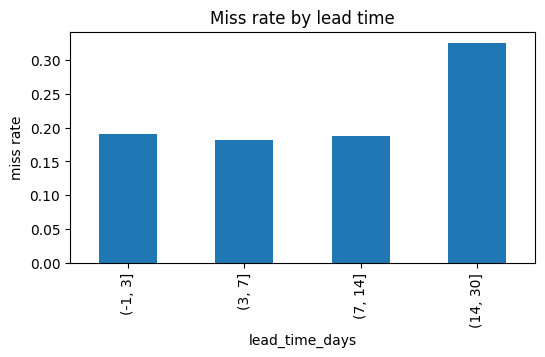

In [2]:
df.groupby(pd.cut(df["lead_time_days"], bins=[-1,3,7,14,30]))["is_missed"].mean().plot(
    kind="bar", figsize=(6,3), title="Miss rate by lead time"
)
plt.ylabel("miss rate"); plt.show()

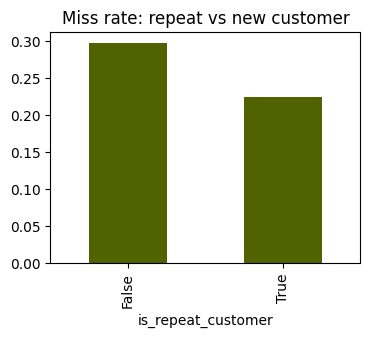

In [3]:
df.groupby("is_repeat_customer")["is_missed"].mean().plot(
    kind="bar", figsize=(4,3), title="Miss rate: repeat vs new customer", color="#506300"
)
plt.show()

/var/folders/rf/4sxqbs3d5tjg8t617zckblyx1rl7px/T/ipykernel_852/1844433707.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df["price"], bins=[0,400,700,2000]))["is_missed"].mean().plot(


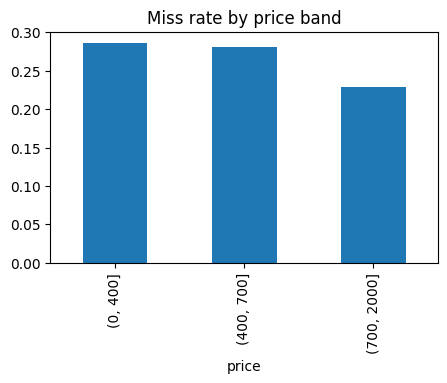

In [4]:
df.groupby(pd.cut(df["price"], bins=[0,400,700,2000]))["is_missed"].mean().plot(
    kind="bar", figsize=(5,3), title="Miss rate by price band"
)
plt.show()

**Pattern check:** miss rate should rise with longer lead time and drop for
repeat customers. Those are the signals we baked into the data — confirming
the model has something real to learn.

## 3. Feature engineering

Same idea as Notebook 1 — turn categoricals into 0/1 columns.

In [5]:
features = pd.get_dummies(
    df[["sport","district","day_of_week","hour","is_weekend","is_holiday",
        "weather","price","lead_time_days","is_repeat_customer"]],
    columns=["sport","district","weather"],
    drop_first=True,
)
target = df["is_missed"]
print("Feature matrix:", features.shape)
features.head()

Feature matrix: (10454, 14)


,day_of_week,hour,is_weekend,is_holiday,price,lead_time_days,is_repeat_customer,sport_Basketball,sport_Football,sport_Padel,district_Sukhumvit,district_Thong Lor,weather_rainy,weather_sunny
0,1,11,False,False,450,2,True,False,False,False,True,False,True,False
1,1,12,False,False,450,6,True,False,False,False,True,False,True,False
2,1,13,False,False,450,23,True,False,False,False,True,False,True,False
3,1,14,False,False,450,29,False,False,False,False,True,False,True,False
4,1,15,False,False,450,23,False,False,False,False,True,False,True,False


## 4. Train/test split — stratified

Because the positive class is rare, a random split could land most of the
no-shows in either train or test by chance. **Stratified split** preserves the
class ratio in both halves.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42, stratify=target
)
print(f"Train miss rate: {y_train.mean():.3f}   Test miss rate: {y_test.mean():.3f}")

Train miss rate: 0.257   Test miss rate: 0.256
